In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('../../data/test.csv')

In [4]:
df.head()

,ID,Gender,DOB,Lead_Creation_Date,City_Code,City_Category,Employer_Code,Employer_Category1,Employer_Category2,Monthly_Income,...,Primary_Bank_Type,Contacted,Source,Source_Category,Existing_EMI,Loan_Amount,Loan_Period,Interest_Rate,EMI,Var1
0,APPA70109647212,Male,03/06/88,05/07/16,C10028,C,COM0002222,A,4.0,2150.0,...,P,Y,S122,B,0.0,10000.0,3.0,20.0,372.0,4
1,APPB10687939341,Male,13/07/81,01/07/16,C10003,A,COM0001784,C,4.0,4200.0,...,P,Y,S133,C,0.0,69000.0,5.0,24.0,1985.0,7
2,APPC80449411414,Female,19/11/90,01/07/16,C10009,B,COM0045260,B,4.0,1000.0,...,P,N,S133,B,0.0,NaN,NaN,NaN,NaN,0
3,APPD30665094501,Female,15/10/92,01/07/16,C10005,A,COM0000085,A,3.0,1465.0,...,P,N,S133,C,0.0,NaN,NaN,NaN,NaN,0
4,APPE80379821637,Male,21/09/88,01/07/16,C10005,A,COM0006422,A,4.0,2340.0,...,P,Y,S143,B,500.0,10000.0,2.0,NaN,NaN,0


In [5]:
df.columns

Index(['ID', 'Gender', 'DOB', 'Lead_Creation_Date', 'City_Code',
       'City_Category', 'Employer_Code', 'Employer_Category1',
       'Employer_Category2', 'Monthly_Income',
       'Customer_Existing_Primary_Bank_Code', 'Primary_Bank_Type', 'Contacted',
       'Source', 'Source_Category', 'Existing_EMI', 'Loan_Amount',
       'Loan_Period', 'Interest_Rate', 'EMI', 'Var1'],
      dtype='object')

In [6]:
df.shape

(30037, 21)

In [7]:
df.isnull().sum()

ID                                         0
Gender                                     0
DOB                                        3
Lead_Creation_Date                         0
City_Code                                314
City_Category                            314
Employer_Code                           1605
Employer_Category1                      1605
Employer_Category2                      1695
Monthly_Income                             0
Customer_Existing_Primary_Bank_Code     4037
Primary_Bank_Type                       4037
Contacted                                  0
Source                                     0
Source_Category                            0
Existing_EMI                              32
Loan_Amount                            11871
Loan_Period                            11871
Interest_Rate                          20385
EMI                                    20385
Var1                                       0
dtype: int64

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30037 entries, 0 to 30036
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   30037 non-null  object 
 1   Gender                               30037 non-null  object 
 2   DOB                                  30034 non-null  object 
 3   Lead_Creation_Date                   30037 non-null  object 
 4   City_Code                            29723 non-null  object 
 5   City_Category                        29723 non-null  object 
 6   Employer_Code                        28432 non-null  object 
 7   Employer_Category1                   28432 non-null  object 
 8   Employer_Category2                   28342 non-null  float64
 9   Monthly_Income                       30037 non-null  float64
 10  Customer_Existing_Primary_Bank_Code  26000 non-null  object 
 11  Primary_Bank_Type           

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employer_Category2,28342.0,3.728248,0.794883,1.00,4.00,4.0,4.0,4.0
Monthly_Income,30037.0,3977.139152,23289.601876,0.00,1650.00,2500.0,4000.0,3500000.0
Existing_EMI,30005.0,348.909060,1000.816847,0.00,0.00,0.0,350.0,43000.0
Loan_Amount,18166.0,39482.990201,30527.865594,5000.00,20000.00,30000.0,50000.0,300000.0
Loan_Period,18166.0,3.903116,1.150820,1.00,3.00,4.0,5.0,6.0
Interest_Rate,9652.0,19.280537,5.882246,11.99,15.25,18.0,20.0,37.0
EMI,9652.0,1094.914836,727.452303,118.00,625.00,946.0,1291.0,6979.0
Var1,30037.0,3.962313,3.821020,0.00,0.00,2.0,7.0,10.0


In [15]:
threshold=len(df)*0.4
df=df.dropna(thresh=threshold,axis=1)

In [16]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(),inplace=True)

print(df.isnull().sum())

ID                                     0
Gender                                 0
DOB                                    0
Lead_Creation_Date                     0
City_Code                              0
City_Category                          0
Employer_Code                          0
Employer_Category1                     0
Employer_Category2                     0
Monthly_Income                         0
Customer_Existing_Primary_Bank_Code    0
Primary_Bank_Type                      0
Contacted                              0
Source                                 0
Source_Category                        0
Existing_EMI                           0
Loan_Amount                            0
Loan_Period                            0
Var1                                   0
dtype: int64


C:\Users\S.B. Engineering\AppData\Local\Temp\ipykernel_9476\2819947111.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)
C:\Users\S.B. Engineering\AppData\Local\Temp\ipykernel_9476\2819947111.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [19]:
df['DOB']=pd.to_datetime(df['DOB'])
today=pd.Timestamp.today()
df['Age']=(today-df['DOB']).dt.days//365
print(df[['DOB','Age']].head())

         DOB  Age
0 1988-03-06   38
1 1981-07-13   44
2 1990-11-19   35
3 1992-10-15   33
4 1988-09-21   37


In [20]:
contact_rate=df['Contacted'].value_counts(normalize=True)*100
print(contact_rate)

Contacted
Y    64.909944
N    35.090056
Name: proportion, dtype: float64


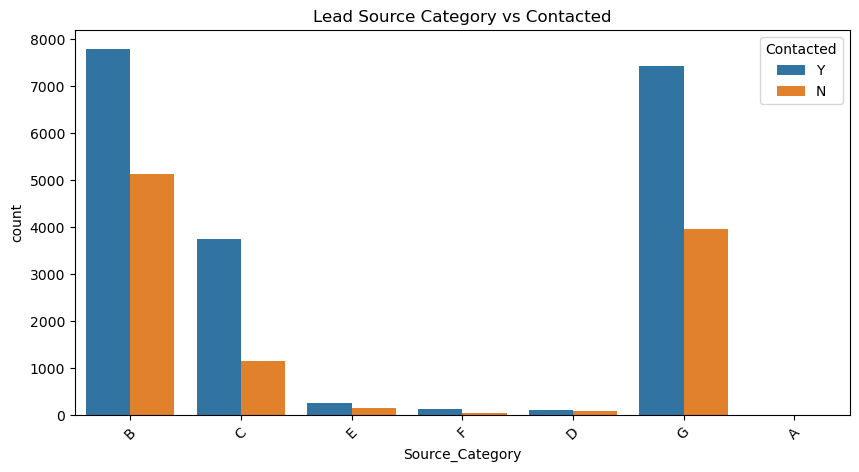

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x='Source_Category',
             hue='Contacted',
             data=df)
plt.xticks(rotation=45)
plt.title("Lead Source Category vs Contacted")
plt.show()

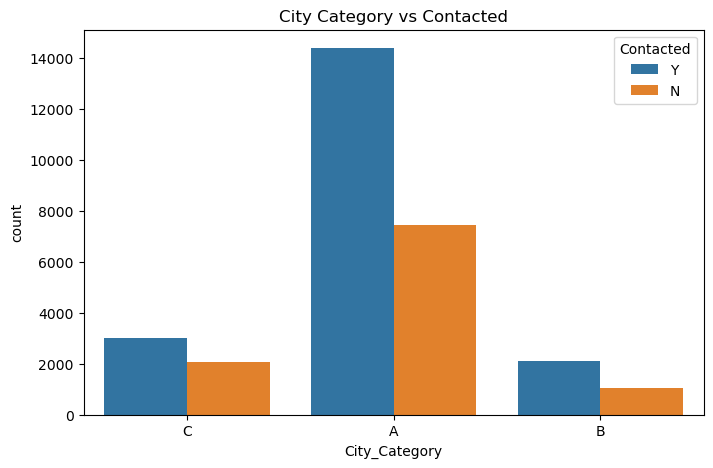

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='City_Category',
             hue='Contacted',
             data=df)

plt.title("City Category vs Contacted")
plt.show()

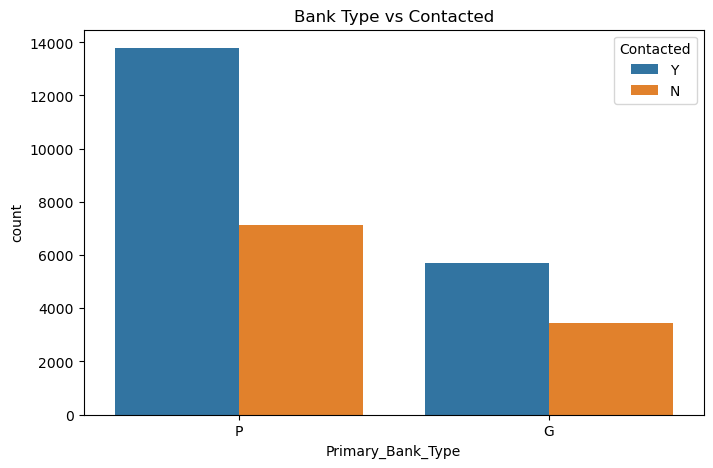

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Bank_Type',
             hue='Contacted',
             data=df)
plt.title("Bank Type vs Contacted")
plt.show()

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

In [110]:
df=pd.read_csv('../../data/test.csv')
df.head()

,ID,Gender,DOB,Lead_Creation_Date,City_Code,City_Category,Employer_Code,Employer_Category1,Employer_Category2,Monthly_Income,...,Primary_Bank_Type,Contacted,Source,Source_Category,Existing_EMI,Loan_Amount,Loan_Period,Interest_Rate,EMI,Var1
0,APPA70109647212,Male,03/06/88,05/07/16,C10028,C,COM0002222,A,4.0,2150.0,...,P,Y,S122,B,0.0,10000.0,3.0,20.0,372.0,4
1,APPB10687939341,Male,13/07/81,01/07/16,C10003,A,COM0001784,C,4.0,4200.0,...,P,Y,S133,C,0.0,69000.0,5.0,24.0,1985.0,7
2,APPC80449411414,Female,19/11/90,01/07/16,C10009,B,COM0045260,B,4.0,1000.0,...,P,N,S133,B,0.0,NaN,NaN,NaN,NaN,0
3,APPD30665094501,Female,15/10/92,01/07/16,C10005,A,COM0000085,A,3.0,1465.0,...,P,N,S133,C,0.0,NaN,NaN,NaN,NaN,0
4,APPE80379821637,Male,21/09/88,01/07/16,C10005,A,COM0006422,A,4.0,2340.0,...,P,Y,S143,B,500.0,10000.0,2.0,NaN,NaN,0


In [111]:
df['DOB'] = pd.to_datetime(df['DOB'])

today = pd.Timestamp.today()

df['Age'] = (today - df['DOB']).dt.days // 365

C:\Users\S.B. Engineering\AppData\Local\Temp\ipykernel_9476\3594002453.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])


In [112]:
df = df.drop(['ID', 'DOB', 'Lead_Creation_Date', 'City_Code',
       'City_Category', 'Employer_Code', 'Employer_Category1',
       'Employer_Category2',
       'Customer_Existing_Primary_Bank_Code', 'Primary_Bank_Type',
       'Source', 'Source_Category', 'Existing_EMI',
       'Loan_Period', 'Var1'], axis=1)


In [113]:
df.head()

,Gender,Monthly_Income,Contacted,Loan_Amount,Interest_Rate,EMI,Age
0,Male,2150.0,Y,10000.0,20.0,372.0,38.0
1,Male,4200.0,Y,69000.0,24.0,1985.0,44.0
2,Female,1000.0,N,NaN,NaN,NaN,35.0
3,Female,1465.0,N,NaN,NaN,NaN,33.0
4,Male,2340.0,Y,10000.0,NaN,NaN,37.0


In [114]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\S.B. Engineering\AppData\Local\Temp\ipykernel_9476\3531623838.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\S.B. Engineering\AppData\Local\Temp\ipykernel_9476\3531623838.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

In [117]:
le=LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col]=le.fit_transform(df[col].astype(str))



df['Contacted'] = le.fit_transform(df['Contacted'])

In [140]:
X=df.drop('Contacted',axis=1)
y=df['Contacted']
X
y

0        1
1        1
2        0
3        0
4        1
        ..
30032    1
30033    1
30034    0
30035    0
30036    1
Name: Contacted, Length: 30037, dtype: int64

In [119]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [120]:
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [121]:
y_pred=model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.992676431424767


In [104]:
pickle.dump(model,open("lead_model.pkl","wb"))